# Performance Estimation Accuracy — Paper Figure

4×6 grid: rows = parallelism strategy, cols = batch size.
Each subfigure compares estimated vs measured RPS per instance type.

In [1]:
import json, glob, os, re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from matplotlib.patches import Patch

BASE_DIR = os.path.dirname(os.path.abspath("__file__"))
WORKLOAD = "in763-out232"
PRED_DIR = os.path.join(BASE_DIR, "trtllm", "llama3-70b", WORKLOAD, "predicted")
MEAS_ROOT = os.path.join(BASE_DIR, "trtllm", "llama3-70b", WORKLOAD, "measured")
FIG_DIR = os.path.join(BASE_DIR, "figures")
os.makedirs(FIG_DIR, exist_ok=True)

EXCLUDE_INSTANCES = ["p4d.24xlarge"]
BATCH_SIZES = [1, 2, 4, 8, 16, 32]
STRATEGIES = [(1, 8), (2, 4), (4, 2), (8, 1)]  # (pp, tp)

INSTANCE_SHORT = {
    "g5.48xlarge": "g5.48xlarge",
    "g6.48xlarge": "g6.48xlarge",
    "g6e.48xlarge": "g6e.48xlarge",
}
INSTANCE_ORDER = ["g5.48xlarge", "g6.48xlarge", "g6e.48xlarge"]

print(f"Predicted: {PRED_DIR}")
print(f"Measured: {MEAS_ROOT}")


Predicted: /home/ubuntu/ShuntServe/ArtifactEvaluation/ReferenceData/PerformanceEstimation/trtllm/llama3-70b/in763-out232/predicted
Measured: /home/ubuntu/ShuntServe/ArtifactEvaluation/ReferenceData/PerformanceEstimation/trtllm/llama3-70b/in763-out232/measured


In [2]:
# ── Data Loading ──

def parse_gptbench_log(filepath):
    metrics = {}
    with open(filepath) as f:
        for line in f:
            if "[BENCHMARK]" not in line: continue
            parts = line.replace("[BENCHMARK] ", "").strip()
            tokens = parts.rsplit(" ", 1)
            if len(tokens) != 2: continue
            key = re.sub(r'\(.*?\)', '', tokens[0]).strip()
            try: metrics[key] = float(tokens[1])
            except: pass
    return metrics

# Predicted
pred_rows = []
for f in sorted(glob.glob(os.path.join(PRED_DIR, "est_*.json"))):
    d = json.load(open(f))
    if not d.get("feasible"): continue
    inst = d["instance_type"]
    if inst in EXCLUDE_INSTANCES: continue
    for e in d.get("batch_sweep", []):
        pred_rows.append({
            "instance": inst, "tp": d["tp_size"], "pp": d["pp_size"],
            "batch": e["batch_size"], "rps_est": e["throughput_rps"],
        })
pred_df = pd.DataFrame(pred_rows)

# Measured
meas_rows = []
for inst_dir in sorted(os.listdir(MEAS_ROOT)):
    log_dir = os.path.join(MEAS_ROOT, inst_dir, "gptBench", "log")
    if not os.path.isdir(log_dir): continue
    inst_name = inst_dir.replace("-", ".")
    if inst_name in EXCLUDE_INSTANCES: continue
    for fp in sorted(glob.glob(os.path.join(log_dir, "trtllm_*.log"))):
        m = re.match(r"trtllm_tp(\d+)_pp(\d+)_bs(\d+)\.log", os.path.basename(fp))
        if not m: continue
        metrics = parse_gptbench_log(fp)
        if not metrics or metrics.get("num_samples", 0) == 0: continue
        ns = int(metrics["num_samples"])
        total = metrics.get("total_latency", 0)
        meas_rows.append({
            "instance": inst_name, "tp": int(m.group(1)), "pp": int(m.group(2)),
            "batch": int(m.group(3)),
            "rps_meas": ns / (total / 1000) if total > 0 else 0,
        })
meas_df = pd.DataFrame(meas_rows)

merged = pd.merge(pred_df, meas_df, on=["instance", "tp", "pp", "batch"])
print(f"Merged: {len(merged)} data points")
print(f"Instances: {sorted(merged['instance'].unique())}")
print(f"Strategies (pp,tp): {sorted(merged.groupby(['pp','tp']).groups.keys())}")
print(f"Batch sizes: {sorted(merged['batch'].unique())}")

Merged: 62 data points
Instances: ['g5.48xlarge', 'g6.48xlarge', 'g6e.48xlarge']
Strategies (pp,tp): [(1, 8), (2, 4), (4, 2), (8, 1)]
Batch sizes: [np.int64(1), np.int64(2), np.int64(4), np.int64(8), np.int64(16), np.int64(32), np.int64(64), np.int64(128)]


Saved to /home/ubuntu/ShuntServe/ArtifactEvaluation/ReferenceData/PerformanceEstimation/figures/estimation_accuracy.{pdf,png}


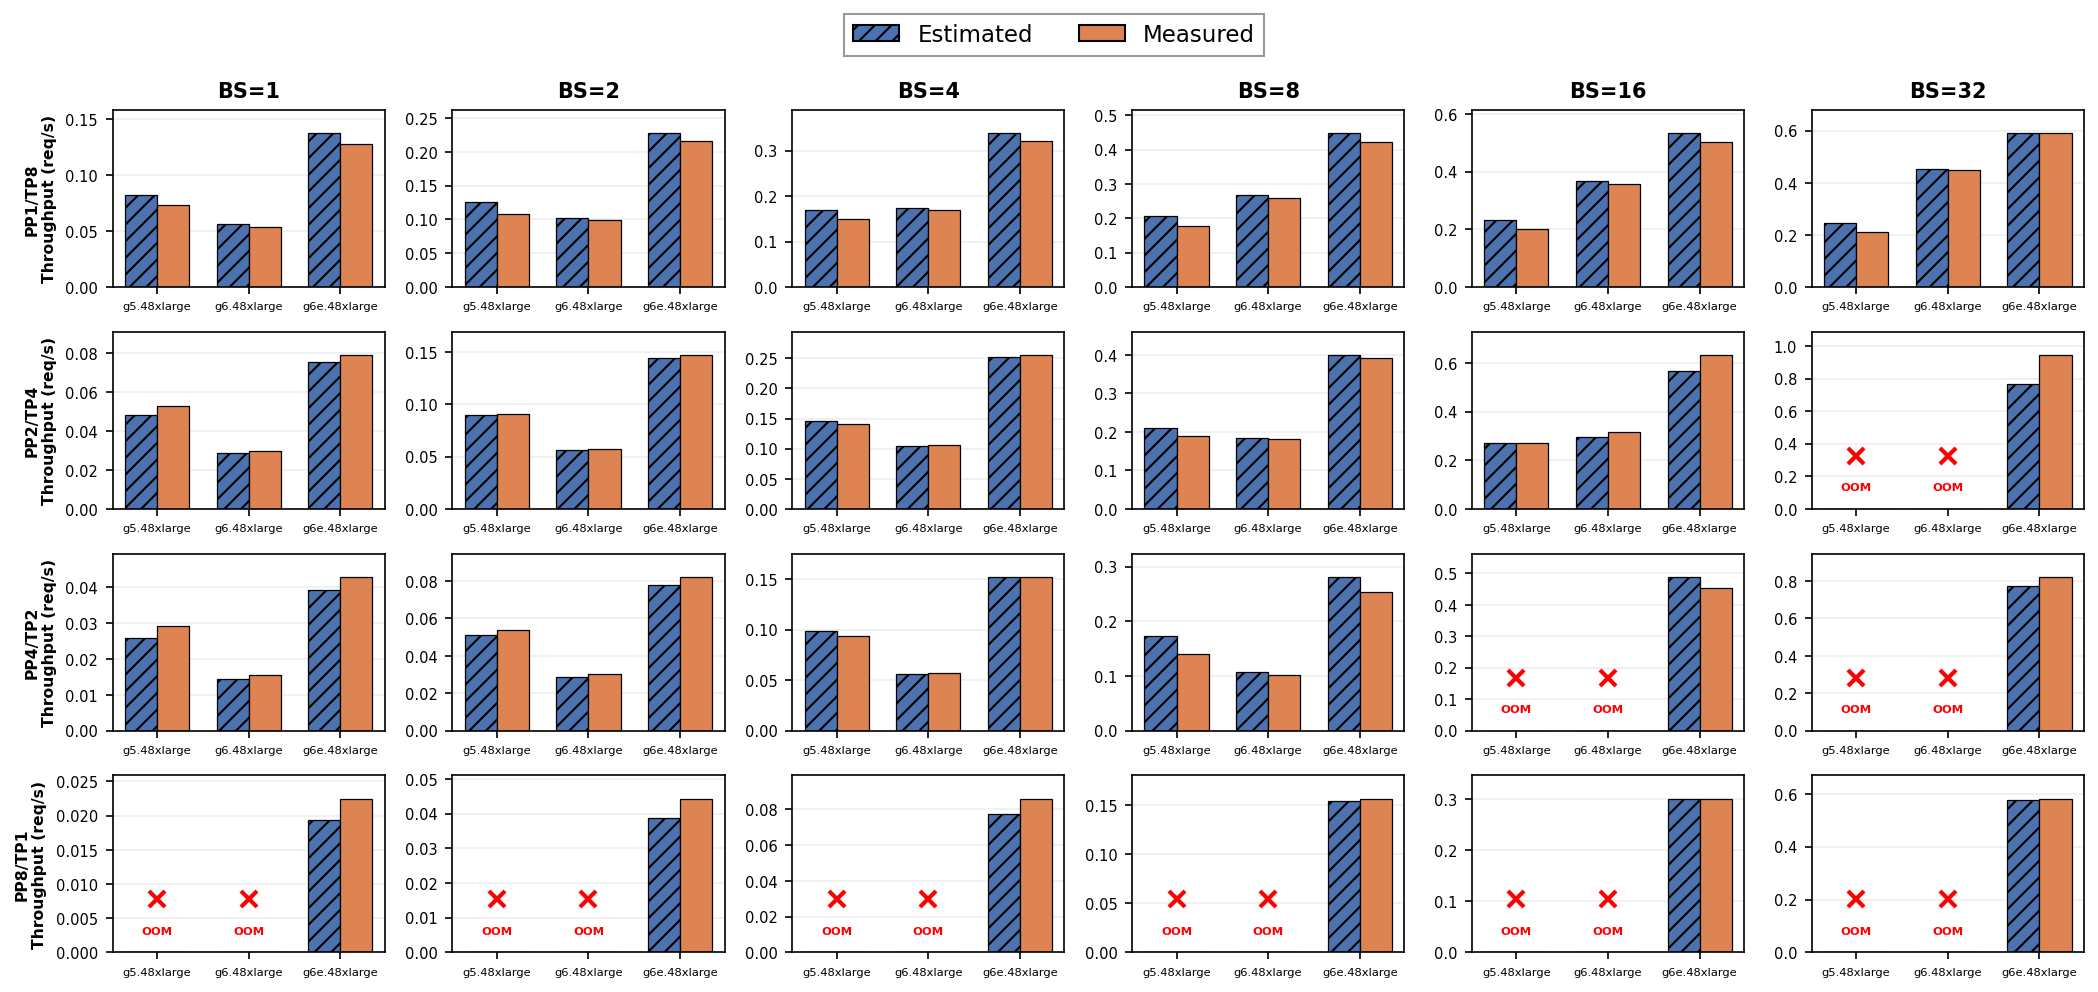

In [3]:
# ── Figure: 4 rows × 6 cols ──

matplotlib.rcParams.update({
    "font.size": 9,
    "axes.labelsize": 10,
    "axes.titlesize": 10,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 10,
    "figure.dpi": 150,
})

C_EST = "#4C72B0"
C_MEAS = "#DD8452"
HATCH_EST = "///"
HATCH_MEAS = ""

n_rows = len(STRATEGIES)
n_cols = len(BATCH_SIZES)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 6.5), squeeze=False)

for row_idx, (pp, tp) in enumerate(STRATEGIES):
    for col_idx, bs in enumerate(BATCH_SIZES):
        ax = axes[row_idx][col_idx]
        sub = merged[(merged["pp"] == pp) & (merged["tp"] == tp) & (merged["batch"] == bs)]
        x = np.arange(len(INSTANCE_ORDER))
        w = 0.35
        xlabels = [INSTANCE_SHORT.get(i, i) for i in INSTANCE_ORDER]

        est_vals, meas_vals, missing = [], [], []
        for idx, inst in enumerate(INSTANCE_ORDER):
            row_data = sub[sub["instance"] == inst]
            if row_data.empty:
                est_vals.append(0); meas_vals.append(0); missing.append(idx)
            else:
                est_vals.append(row_data["rps_est"].values[0])
                meas_vals.append(row_data["rps_meas"].values[0])

        ax.bar(x - w/2, est_vals, w, color=C_EST, edgecolor="black", linewidth=0.6, hatch=HATCH_EST)
        ax.bar(x + w/2, meas_vals, w, color=C_MEAS, edgecolor="black", linewidth=0.6, hatch=HATCH_MEAS)

        ax.set_ylim(bottom=0)
        # Auto y-lim per subfig, then add headroom
        if not sub.empty:
            local_max = max(max(est_vals), max(meas_vals))
            ax.set_ylim(0, local_max * 1.15)

        # Mark missing data
        ymax = ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else 1
        for idx in missing:
            ax.plot(x[idx], ymax * 0.3, marker="x", markersize=8, color="red", markeredgewidth=2, zorder=5)
            ax.text(x[idx], ymax * 0.12, "OOM", fontsize=5.5, ha="center", va="center",
                    color="red", fontweight="bold")

        ax.set_xticks(x)
        ax.set_xticklabels(xlabels, fontsize=5.5)
        if col_idx == 0:
            ax.set_ylabel(f"PP{pp}/TP{tp}\nThroughput (req/s)", fontsize=7.5, fontweight="bold")
        if row_idx == 0:
            ax.set_title(f"BS={bs}", fontsize=10, fontweight="bold")
        ax.tick_params(axis="y", labelsize=7)
        ax.grid(True, alpha=0.2, axis="y")
        ax.set_axisbelow(True)

legend_elements = [
    Patch(facecolor=C_EST, edgecolor="black", hatch=HATCH_EST, label="Estimated"),
    Patch(facecolor=C_MEAS, edgecolor="black", hatch=HATCH_MEAS, label="Measured"),
]
fig.legend(handles=legend_elements, loc="upper center", ncol=2, frameon=True, fontsize=11,
    bbox_to_anchor=(0.5, 1.02), edgecolor="gray", fancybox=False)
fig.tight_layout(rect=[0, 0, 1, 0.96])
fig.savefig(os.path.join(FIG_DIR, "estimation_accuracy.pdf"), bbox_inches="tight", dpi=600)
fig.savefig(os.path.join(FIG_DIR, "estimation_accuracy.png"), bbox_inches="tight", dpi=600)
print(f"Saved to {FIG_DIR}/estimation_accuracy.{{pdf,png}}")
plt.show()
